In [10]:
import Kea
from Kea.utils import plotting, funcs
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 2
N = 256
L = 2.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L
dx = L/N

In [11]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
np.random.seed(1234)
fields = []
for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,)))
energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))

models = []
specs = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    kmesh = spectra_base.wavenumber_mesh(kD)

    _km, _fekm, width = statistics_base.bin_data(kmesh, fekD,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='true_center',
            cut_excess=True, nan_small=False)
    specs.append((_km, _fekm))

    fekD_model = funcs.pure_pow(kmesh, (alphas[i],))
    var = np.nansum(fekD_model * (dk/twopi)**D)
    fekD_model = fekD_model / var
    k_model, fek_model, w = statistics_base.bin_data(kmesh, fekD_model,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='true_center',
            cut_excess=True, nan_small=False)
    models.append((k_model, fek_model))


/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:42: RuntimeWarning: divide by zero encountered in reciprocal
  pl = xx**(alphas[0])
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:42: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:42: RuntimeWarning: divide by zero encountered in reciprocal
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:42: RuntimeWarning: divide by

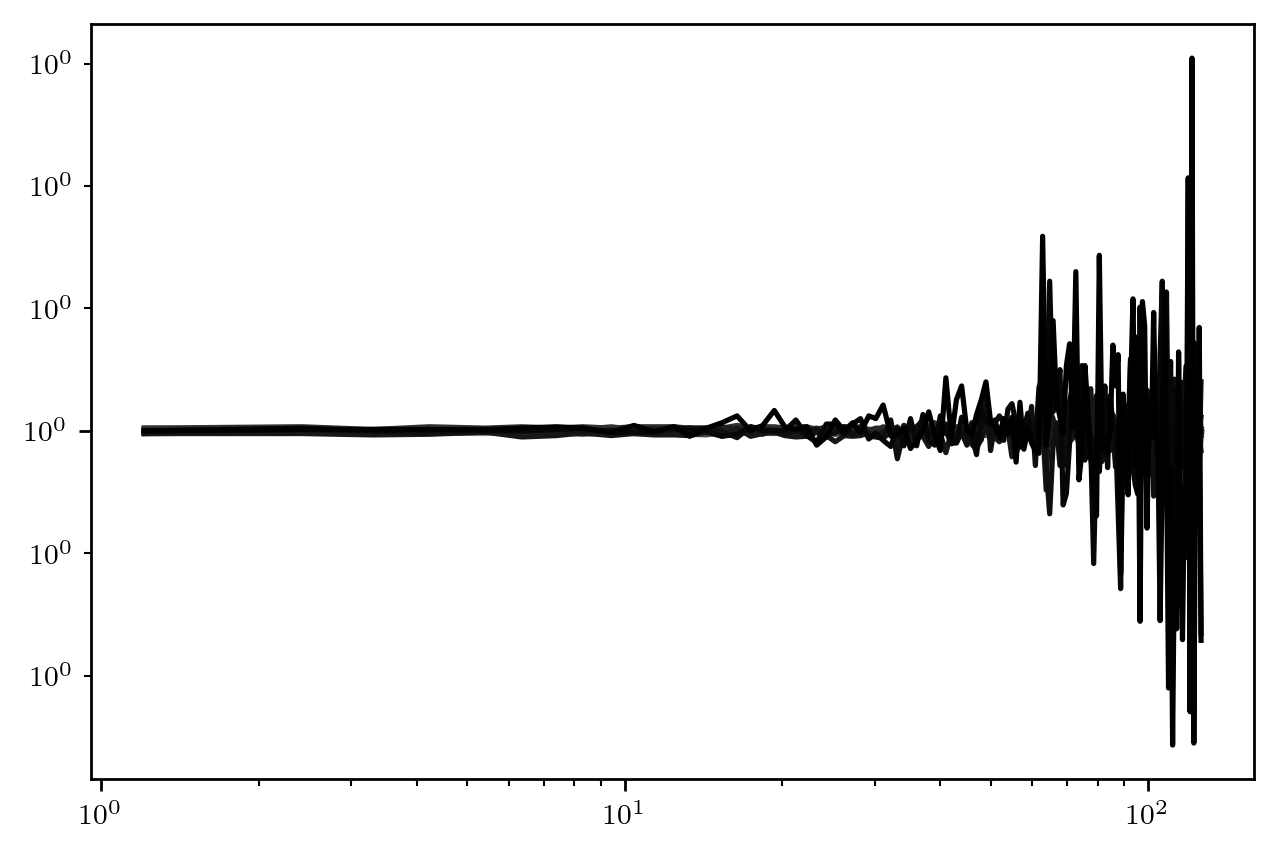

In [12]:
cols = plt.cm.Greys(np.linspace(0.5, 1., NUM))
bias = []

for i in range(len(specs)):
    pk, pfek = models[i]
    ak, afek = specs[i]
    plt.loglog(ak, afek / pfek, color=cols[i])
    bias.append((ak, afek / pfek))

In [13]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
np.random.seed(1234)
fields = []
models = []

BREAK = N//5 * dk
DELTA = 0.1

for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a, -10.), gfunc='smooth_pow', func_kwargs={'breaks': (BREAK,), 'delta': DELTA}))

energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))

models = []
specs = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    kmesh = spectra_base.wavenumber_mesh(kD)

    _km, _fekm, width = statistics_base.bin_data(kmesh, fekD,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='true_center',
            cut_excess=True, nan_small=False)
    specs.append((_km, _fekm))

    fekD_model = funcs.smooth_pow(kmesh, (alphas[i], -10.), (BREAK,), delta=DELTA)
    var = np.nansum(fekD_model * (dk/twopi)**D)
    fekD_model = fekD_model / var
    k_model, fek_model, w = statistics_base.bin_data(kmesh, fekD_model,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='true_center',
            cut_excess=True, nan_small=False)
    models.append((k_model, fek_model))

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:98: RuntimeWarning: divide by zero encountered in reciprocal
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:98: RuntimeWarning: divide by zero encountered in power
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:98: RuntimeWarning: divide by zero encountered in reciprocal
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: Runti

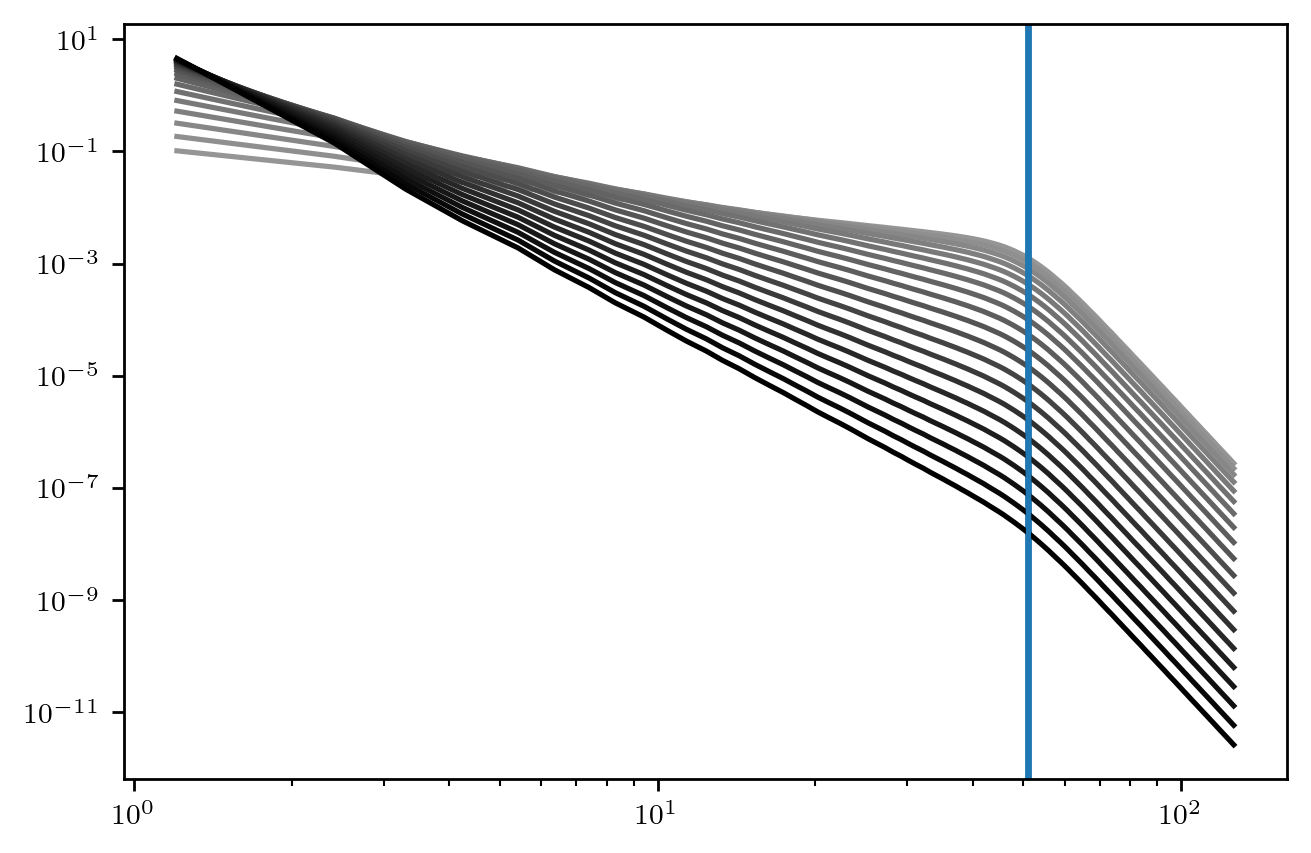

In [14]:
cols = plt.cm.Greys(np.linspace(0.5, 1., NUM))
bias = []

for i in range(len(specs)):
    pk, pfek = models[i]
    ak, afek = specs[i]
    plt.loglog(ak, afek, color=cols[i])
    plt.axvline(BREAK)

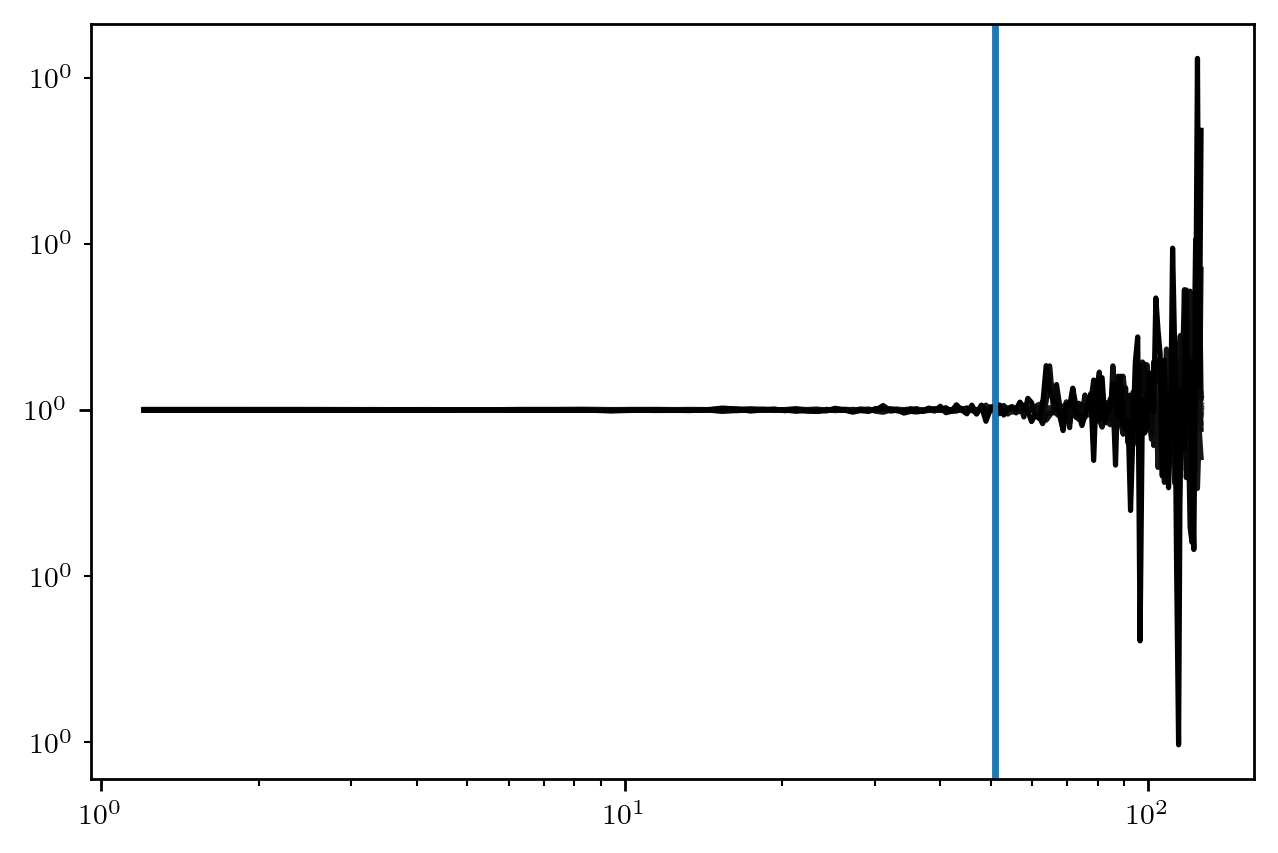

In [15]:
cols = plt.cm.Greys(np.linspace(0.5, 1., NUM))
bias = []

for i in range(len(specs)):
    pk, pfek = models[i]
    ak, afek = specs[i]
    plt.plot(ak, afek / pfek, color=cols[i])
    bias.append((ak, afek / pfek))
    plt.axvline(BREAK)

plt.xscale('log')
plt.yscale('log')

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:98: RuntimeWarning: divide by zero encountered in reciprocal
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:98: RuntimeWarning: divide by zero encountered in power
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:98: RuntimeWarning: divide by zero encountered in reciprocal
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: Runti

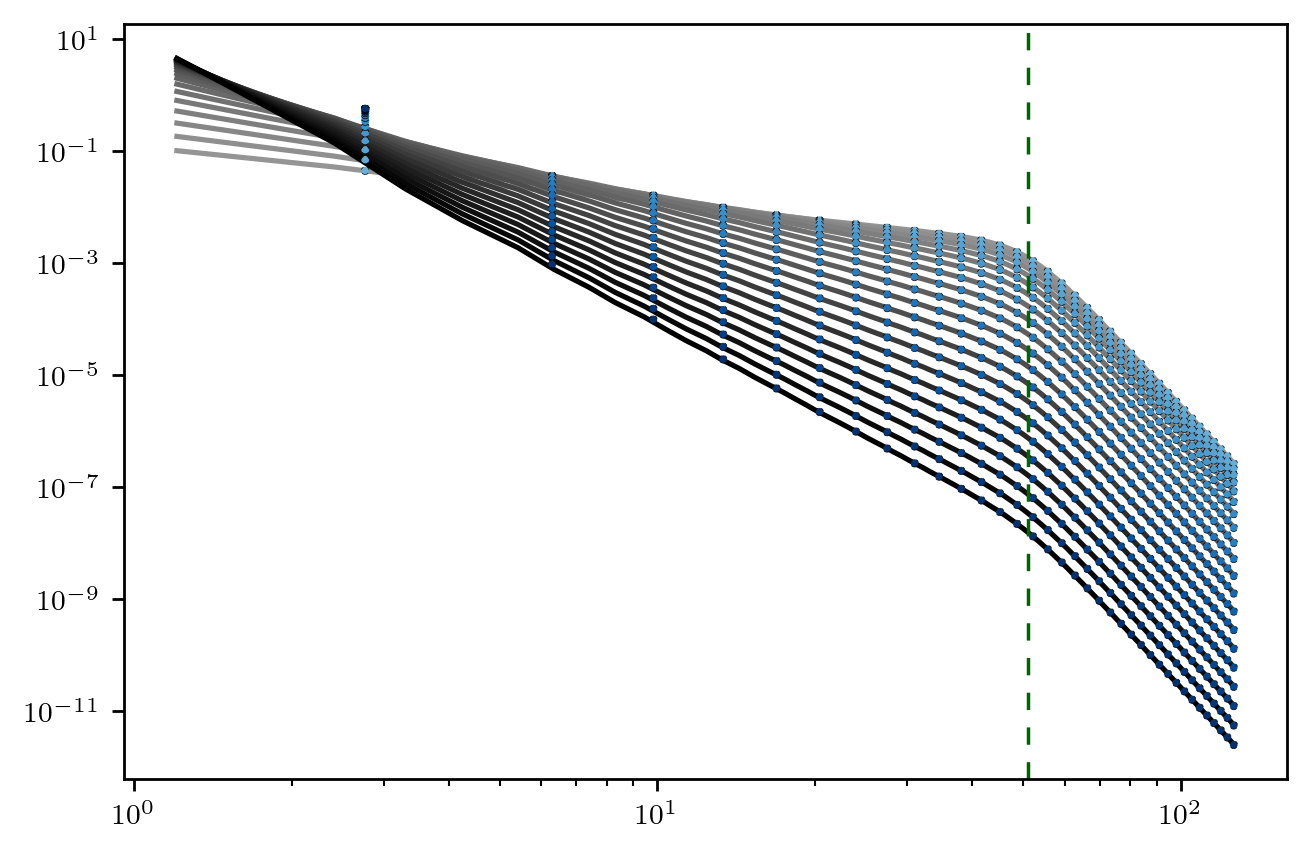

In [16]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
np.random.seed(1234)
fields = []
models = []

BREAK = N//5 * dk
DELTA = 0.1

for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a, -10.), gfunc='smooth_pow', func_kwargs={'breaks': (BREAK,), 'delta': DELTA}))

energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))

models = []
specs = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    kmesh = spectra_base.wavenumber_mesh(kD)

    _km, _fekm, width = statistics_base.bin_data(kmesh, fekD,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='center',
            cut_excess=True, nan_small=False, num_bins=N//5)
    specs.append((_km, _fekm))

    fekD_model = funcs.smooth_pow(kmesh, (alphas[i], -10.), (BREAK,), delta=DELTA)
    var = np.nansum(fekD_model * (dk/twopi)**D)
    fekD_model = fekD_model / var
    k_model, fek_model, w = statistics_base.bin_data(kmesh, fekD_model,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='true_center',
            cut_excess=True, nan_small=False)
    models.append((k_model, fek_model))

cols = plt.cm.Greys(np.linspace(0.5, 1., NUM))
cols2 = plt.cm.Blues(np.linspace(0.5, 1., NUM))
bias = []
for i in range(len(specs)):
    mk, mfek = models[i]
    pk, pfek = specs[i]
    plt.loglog(mk, mfek, color=cols[i], zorder=0)
    plt.scatter(pk, pfek, linestyle=(0,(5,5)), color=cols2[i], marker='o', s=5., zorder=2, linewidth=0.2, edgecolor='black')

plt.axvline(BREAK, linestyle=(0,(5,5)), color='darkgreen', linewidth=1.)

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:98: RuntimeWarning: divide by zero encountered in reciprocal
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:98: RuntimeWarning: divide by zero encountered in power
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:98: RuntimeWarning: divide by zero encountered in reciprocal
  pl = (xx/bb)**(-a1) * (0.5 * (1. + (xx/bb)**(1./delta)))**((a1 - a2)*delta)
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: Runti

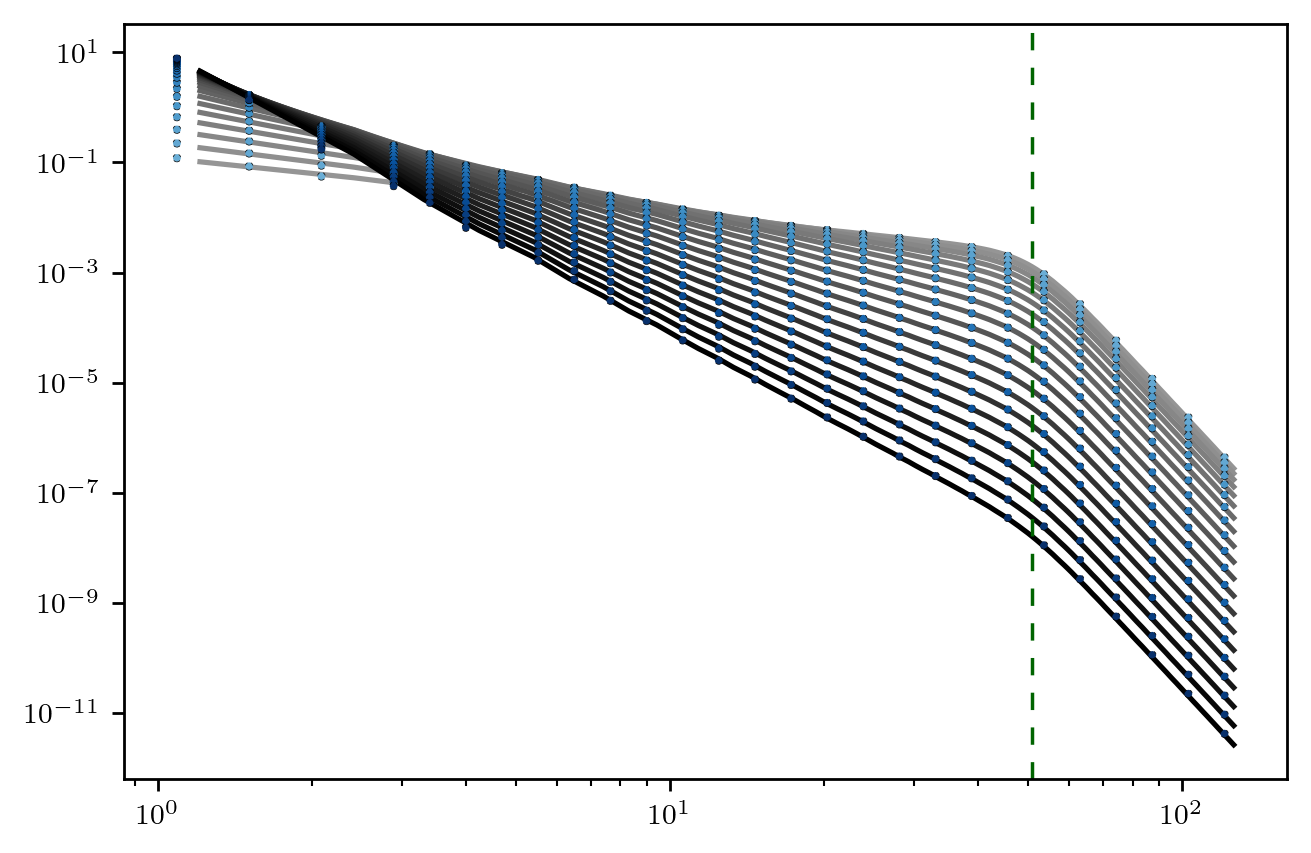

In [17]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
np.random.seed(1234)
fields = []
models = []

BREAK = N//5 * dk
DELTA = 0.1

for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a, -10.), gfunc='smooth_pow', func_kwargs={'breaks': (BREAK,), 'delta': DELTA}))

energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))

models = []
specs = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    kmesh = spectra_base.wavenumber_mesh(kD)

    _km, _fekm, width = statistics_base.bin_data(kmesh, fekD,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='center',
            cut_excess=True, nan_small=False, num_bins=N//8, log_space=True)
    specs.append((_km, _fekm))

    fekD_model = funcs.smooth_pow(kmesh, (alphas[i], -10.), (BREAK,), delta=DELTA)
    var = np.nansum(fekD_model * (dk/twopi)**D)
    fekD_model = fekD_model / var
    k_model, fek_model, w = statistics_base.bin_data(kmesh, fekD_model,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='true_center',
            cut_excess=True, nan_small=False)
    models.append((k_model, fek_model))

cols = plt.cm.Greys(np.linspace(0.5, 1., NUM))
cols2 = plt.cm.Blues(np.linspace(0.5, 1., NUM))
bias = []
for i in range(len(specs)):
    mk, mfek = models[i]
    pk, pfek = specs[i]
    plt.loglog(mk, mfek, color=cols[i], zorder=0)
    plt.scatter(pk, pfek, linestyle=(0,(5,5)), color=cols2[i], marker='o', s=5., zorder=2, linewidth=0.2, edgecolor='black')

plt.axvline(BREAK, linestyle=(0,(5,5)), color='darkgreen', linewidth=1.)

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:70: RuntimeWarning: divide by zero encountered in true_divide
  pl = np.exp(-bb/xx) * xx**(a1)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:70: RuntimeWarning: divide by zero encountered in reciprocal
  pl = np.exp(-bb/xx) * xx**(a1)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:70: RuntimeWarning: invalid value encountered in multiply
  pl = np.exp(-bb/xx) * xx**(a1)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:70: RuntimeWarning: divide by zero encountered in power
  pl = np.exp(-bb/xx) * xx**(a1)
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:70: RuntimeWarning: divide by zero encountered in true_divide
  pl = np.exp(-bb/xx) * xx**(a1)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:70: RuntimeWarning: divide by zero enc

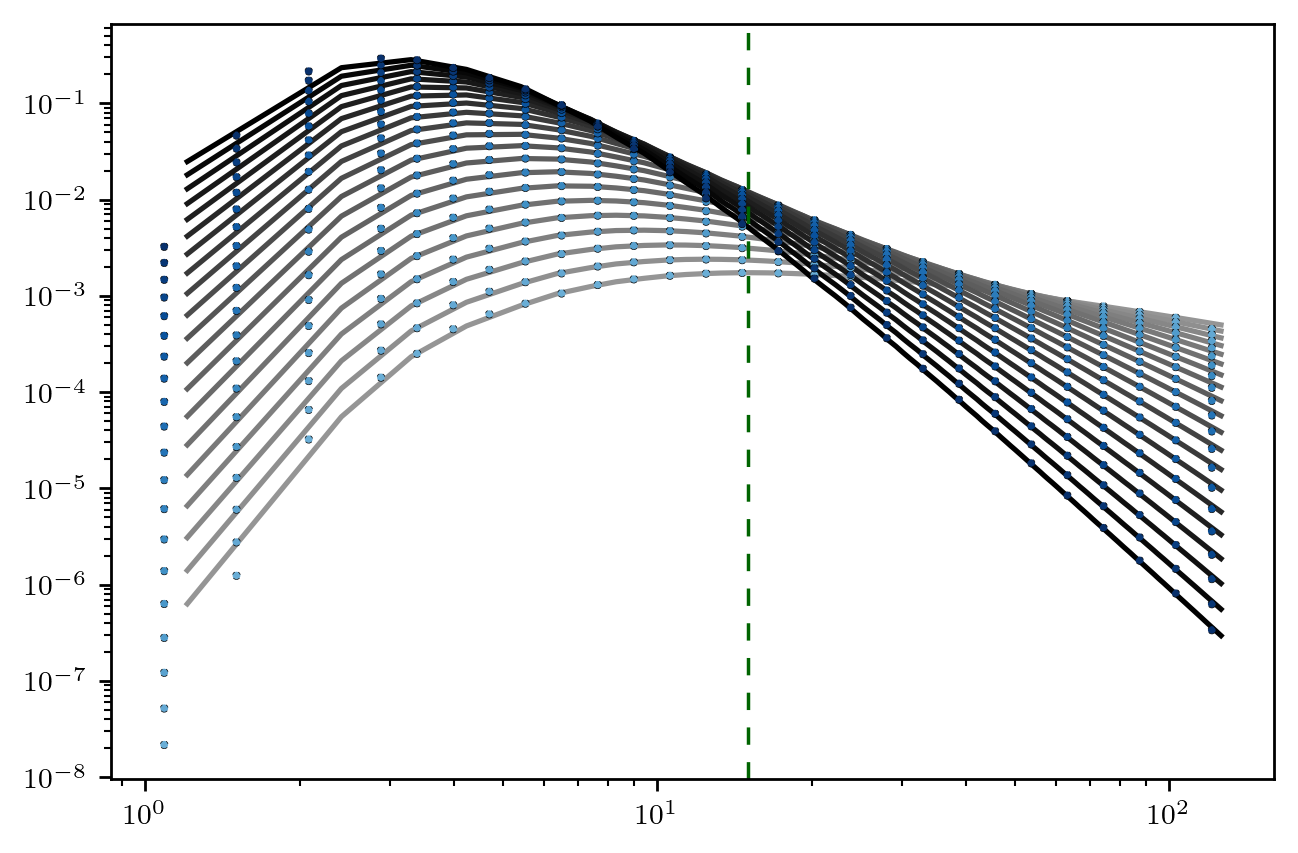

In [19]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
np.random.seed(1234)
fields = []
models = []

BREAK = 15 * dk

for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), gfunc='exp_pow', func_kwargs={'breaks': (BREAK,)}))

energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))

models = []
specs = []
for i, f in enumerate(fields):
    kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    kmesh = spectra_base.wavenumber_mesh(kD)

    _km, _fekm, width = statistics_base.bin_data(kmesh, fekD,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='center',
            cut_excess=True, nan_small=False, num_bins=N//8, log_space=True)
    specs.append((_km, _fekm))

    fekD_model = funcs.exp_pow(kmesh, (alphas[i],), (BREAK,))
    var = np.nansum(fekD_model * (dk/twopi)**D)
    fekD_model = fekD_model / var
    k_model, fek_model, w = statistics_base.bin_data(kmesh, fekD_model,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='true_center',
            cut_excess=True, nan_small=False)
    models.append((k_model, fek_model))

cols = plt.cm.Greys(np.linspace(0.5, 1., NUM))
cols2 = plt.cm.Blues(np.linspace(0.5, 1., NUM))
bias = []
for i in range(len(specs)):
    mk, mfek = models[i]
    pk, pfek = specs[i]
    plt.loglog(mk, mfek, color=cols[i], zorder=0)
    plt.scatter(pk, pfek, linestyle=(0,(5,5)), color=cols2[i], marker='o', s=5., zorder=2, linewidth=0.2, edgecolor='black')

plt.axvline(BREAK, linestyle=(0,(5,5)), color='darkgreen', linewidth=1.)